# Supplementary Figure S1: Illustration of Decoration

This notebook draws the local graph replacement used to decorate an undecorated coupling graph.

This figure includes:

* an undecorated patch with original bulk nodes and couplings
* the decorated replacement with split nodes on every original edge
* boundary legs attached to the decorated bulk nodes
* positive and negative decorated couplings


## Import Dependencies

In [1]:
%load_ext autoreload
%autoreload 2

import os
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "global_figure_settings.toml").exists():
    REPO_ROOT = REPO_ROOT.parent
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
os.chdir(REPO_ROOT)

os.environ.setdefault("MPLCONFIGDIR", str((REPO_ROOT / "outputs" / "mplconfig").resolve()))
Path(os.environ["MPLCONFIGDIR"]).mkdir(parents=True, exist_ok=True)

import matplotlib.pyplot as plt
import numpy as np

import loadconfig as loco
from graph2grav.figure_hashing import save_figure_with_hash


## Set Parameters

Collect the drawing settings and color palette for the schematic.

In [2]:
SETTINGS = {
    "figsize": (7.0, 5.8),
    "dpi": 250,
    "output_stem": "figures/supplementary-figure_illustration_of_decoration",
    "node_size": 250,
    "node_linewidth": 1.3,
    "edge_width": 2.8,
    "label_size": 14,
    "sign_size": 24,
    "left_x_offset": -2.2,
    "right_x_offset": 2.0,
}

config = loco.reload()
colors = {
    "bulk_fill": config["graph"]["nodes"]["ancilla"]["inner"]["color"],
    "bulk_edge": config["graph"]["nodes"]["ancilla"]["outer"]["color"],
    "boundary_fill": config["graph"]["nodes"]["boundary"]["inner"]["color"],
    "boundary_edge": config["graph"]["nodes"]["boundary"]["outer"]["color"],
    "split_fill": config["graph"]["nodes"]["ancilla_secondary"]["inner"]["color"],
    "split_edge": config["graph"]["nodes"]["ancilla_secondary"]["outer"]["color"],
    "split_label": config["graph"]["nodes"]["ancilla_secondary"]["outer"]["color"],
    "positive_edge": config["decorated-figure"]["edges"]["positive"]["color"],
    "negative_edge": config["decorated-figure"]["edges"]["negative"]["color"],
    "undecorated_edge": "#5a5a5a",
}


## Define Drawing Helpers

Define small helpers for drawing nodes, couplings, and the undecorated/decorated patches.

In [3]:
def draw_edge(ax, p0, p1, color, width=None, zorder=1):
    if width is None:
        width = SETTINGS["edge_width"]
    ax.plot(
        [p0[0], p1[0]],
        [p0[1], p1[1]],
        color=color,
        linewidth=width,
        solid_capstyle="round",
        zorder=zorder,
    )


def draw_node(ax, xy, facecolor, edgecolor, size=None, zorder=5):
    if size is None:
        size = SETTINGS["node_size"]
    ax.scatter(
        [xy[0]],
        [xy[1]],
        s=size,
        facecolor=facecolor,
        edgecolor=edgecolor,
        linewidth=SETTINGS["node_linewidth"],
        zorder=zorder,
    )


def shifted(points, x_offset):
    return {name: np.array([xy[0] + x_offset, xy[1]]) for name, xy in points.items()}


def draw_undecorated_patch(ax, colors):
    points = shifted(
        {
            "upper_left": (-1.0, 1.0),
            "upper_right": (1.0, 1.0),
            "lower_left": (-1.0, -1.0),
            "lower_right": (1.0, -1.0),
            "center": (-0.05, 0.05),
        },
        SETTINGS["left_x_offset"],
    )

    for u, v in [
        ("upper_left", "upper_right"),
        ("upper_right", "lower_right"),
        ("lower_right", "lower_left"),
        ("lower_left", "upper_left"),
        ("upper_left", "center"),
        ("center", "lower_right"),
    ]:
        draw_edge(ax, points[u], points[v], colors["undecorated_edge"])

    for xy in points.values():
        draw_node(ax, xy, colors["bulk_fill"], colors["bulk_edge"])

    ax.text(
        points["upper_left"][0] - 0.05,
        points["upper_left"][1] + 0.38,
        "bulk nodes",
        color=colors["bulk_edge"],
        fontsize=SETTINGS["label_size"],
        ha="left",
        va="center",
    )


def draw_decorated_patch(ax, colors):
    points = shifted(
        {
            "upper_left": (-1.0, 1.0),
            "upper_right": (1.0, 1.0),
            "lower_left": (-1.0, -1.0),
            "lower_right": (1.0, -1.0),
            "diag_1": (-0.5, 0.5),
            "diag_bulk": (0.0, 0.0),
            "diag_2": (0.5, -0.5),
            "top_split": (0.0, 1.0),
            "left_split": (-1.0, 0.0),
            "bottom_split": (0.0, -1.0),
            "right_split": (1.0, 0.0),
            "boundary_upper_left": (-1.45, 1.45),
            "boundary_lower_left": (-1.45, -1.45),
            "boundary_upper_right": (1.45, 1.45),
            "boundary_lower_right": (1.45, -1.45),
        },
        SETTINGS["right_x_offset"],
    )

    positive = colors["positive_edge"]
    negative = colors["negative_edge"]

    decorated_edges = [
        ("upper_left", "top_split", negative),
        ("top_split", "upper_right", positive),
        ("upper_left", "left_split", positive),
        ("left_split", "lower_left", negative),
        ("lower_left", "bottom_split", positive),
        ("bottom_split", "lower_right", negative),
        ("upper_right", "right_split", negative),
        ("right_split", "lower_right", positive),
        ("upper_left", "diag_1", positive),
        ("diag_1", "diag_bulk", negative),
        ("diag_bulk", "diag_2", positive),
        ("diag_2", "lower_right", negative),
    ]
    for u, v, color in decorated_edges:
        draw_edge(ax, points[u], points[v], color)

    for u, v in [
        ("boundary_upper_left", "upper_left"),
        ("boundary_lower_left", "lower_left"),
        ("boundary_upper_right", "upper_right"),
        ("boundary_lower_right", "lower_right"),
    ]:
        draw_edge(ax, points[u], points[v], "black")

    for node in ["upper_left", "upper_right", "lower_left", "lower_right", "diag_bulk"]:
        draw_node(ax, points[node], colors["bulk_fill"], colors["bulk_edge"])

    for node in ["top_split", "left_split", "bottom_split", "right_split", "diag_1", "diag_2"]:
        draw_node(ax, points[node], colors["split_fill"], colors["split_edge"])

    for node in [
        "boundary_upper_left",
        "boundary_lower_left",
        "boundary_upper_right",
        "boundary_lower_right",
    ]:
        draw_node(ax, points[node], colors["boundary_fill"], colors["boundary_edge"])

    ax.text(
        points["upper_left"][0] - 0.2,
        points["boundary_upper_left"][1] + 0.02,
        "boundary nodes",
        color=colors["boundary_edge"],
        fontsize=SETTINGS["label_size"],
        ha="left",
        va="center",
    )
    ax.text(
        points["diag_1"][0] + 0.25,
        points["diag_1"][1] + 0.03,
        "split nodes",
        color=colors["split_label"],
        fontsize=SETTINGS["label_size"],
        ha="left",
        va="center",
    )
    ax.text(
        points["left_split"][0] - 0.2,
        0.35,
        "+",
        color=positive,
        fontsize=SETTINGS["sign_size"],
        fontweight="bold",
        ha="center",
        va="center",
    )
    ax.text(
        points["left_split"][0] - 0.2,
        -0.35,
        "-",
        color=negative,
        fontsize=SETTINGS["sign_size"],
        fontweight="bold",
        ha="center",
        va="center",
    )


## Make Figure

Draw and save the PNG preview and PDF paper figure.

Saved figures/supplementary-figure_illustration_of_decoration.png
Saved figure to figures/supplementary-figure_illustration_of_decoration.pdf. Hash info updated in figures/.hashes.json; history in figures/.hash_history.json. file_hash=1d56971fbdeb262f, data_hash=d3c7aeb30efbc6d8, size=12779 bytes.


{'file_hash': '1d56971fbdeb262f',
 'data_hash': 'd3c7aeb30efbc6d8',
 'size': 12779}

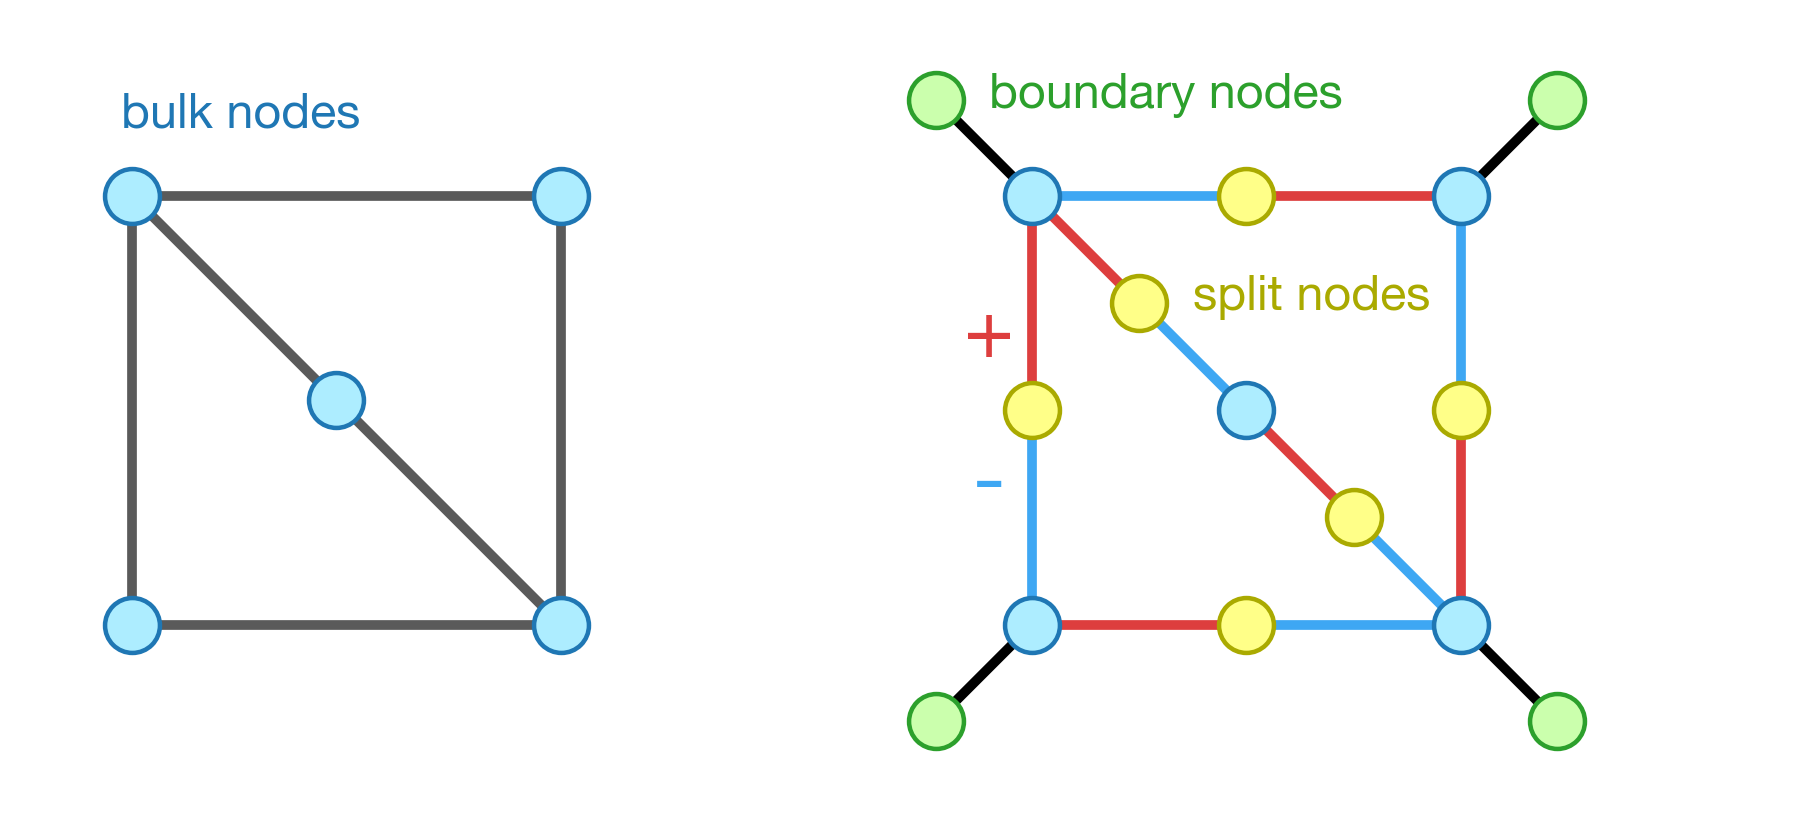

In [ ]:
fig, ax = plt.subplots(figsize=SETTINGS["figsize"], dpi=SETTINGS["dpi"])
draw_undecorated_patch(ax, colors)
draw_decorated_patch(ax, colors)

ax.set_aspect("equal")
ax.set_xlim(-3.7, 4.45)
ax.set_ylim(-1.8, 1.8)
ax.axis("off")
fig.tight_layout(pad=0.05)

output_stem = Path(SETTINGS["output_stem"])
output_stem.parent.mkdir(parents=True, exist_ok=True)
# png_path = output_stem.with_suffix(".png")
pdf_path = output_stem.with_suffix(".pdf")
# fig.savefig(png_path, bbox_inches="tight", pad_inches=0.02)
# print(f"Saved {png_path}")
save_figure_with_hash(fig, pdf_path, bbox_inches="tight", pad_inches=0.02)
